In [11]:
import torchvision.transforms as transforms
import torchvision
import torch.nn as nn
import torch.optim as optim
import torch

import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


from tqdm import tqdm
import copy
import random

## Seeding ensures reproducibilit, device is ensuring we send it to GPU 
torch.manual_seed(0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Transform to Grayscale, then to tensor, then nomalise
transform = transforms.Compose(
    [transforms.Grayscale(),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5)),
    ])

## Call in the data from the files, and their split , further down we will split further for test. 
trainval_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/trainval', transform = transform)
train_portion = 0.8
val_portion = 0.2

## split the indexes and targets 
all_indexes = np.arange(len(trainval_dataset))
all_targets = trainval_dataset.targets

## Split the dataset indexes into train and val idx, Assign the train size, stratify ensures class distribution is even an drandom state for reproducibility.  
train_idx, val_idx = train_test_split(all_indexes, train_size=train_portion, stratify = all_targets, random_state = 0)

## Create the separate bookcases and store them. Input the dataset and the train idx and val idx that will be in the bookcase. 
train_dataset = torch.utils.data.Subset(trainval_dataset, train_idx)
val_dataset = torch.utils.data.Subset(trainval_dataset, val_idx)

## Assign the test dataset, no need to split. 
test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20//test', transform = transform)

## Batch size is the amount of images we iterate over before we update weights. 
## So we update the weight after 16 images until we go through the whole dataset. when the whole dataset is completed we complete an epoch. 
batch_size = 16


## these are my loades into the model, insert the datasets, batch size is as stated before, you only shuffle 
## training set so it doesnt learn on loading order, number of workers is just helpers, that prepare and load. 
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers = 2)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=False, num_workers = 2)

print(f"Using device: {device}")

Using device: cuda:0


In [12]:
#Check the dataset is there. 
print(f'Size of train dataset: {len(train_dataset)}')
print(f'Size of val dataset: {len(val_dataset)}')
print(f'Size of test dataset: {len(test_dataset)}')

Size of train dataset: 1064
Size of val dataset: 267
Size of test dataset: 669


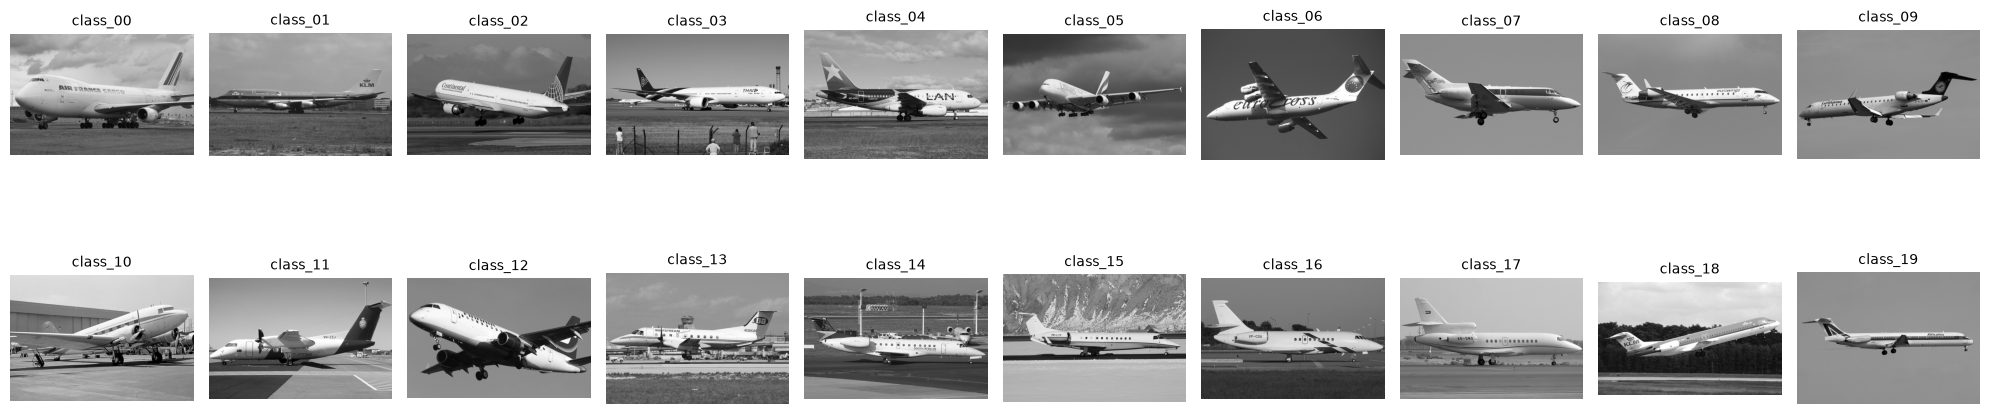

In [13]:
# Plot one random sample from each class in a horizontal stripe
num_classes = 20
fig, axes = plt.subplots(2, 10, figsize=(20, 6))

# Get class names
class_names = trainval_dataset.classes
dataset_labels = np.array([label for _, label in trainval_dataset.samples])

# For each class, find one sample and plot it
for class_idx in range(num_classes):
    class_indices = np.where(dataset_labels == class_idx)[0] 
    
    # Pick a random sample from this class
    sample_idx = np.random.choice(class_indices)
    
    # Load and display the image    # Load and display the image
    img, _ = trainval_dataset[sample_idx]
    
    row, col = int(class_idx // 10), int(class_idx % 10)
    axes[row, col].imshow(img.squeeze(0), cmap='gray')
    axes[row, col].set_title(class_names[class_idx].split('-')[-1], fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

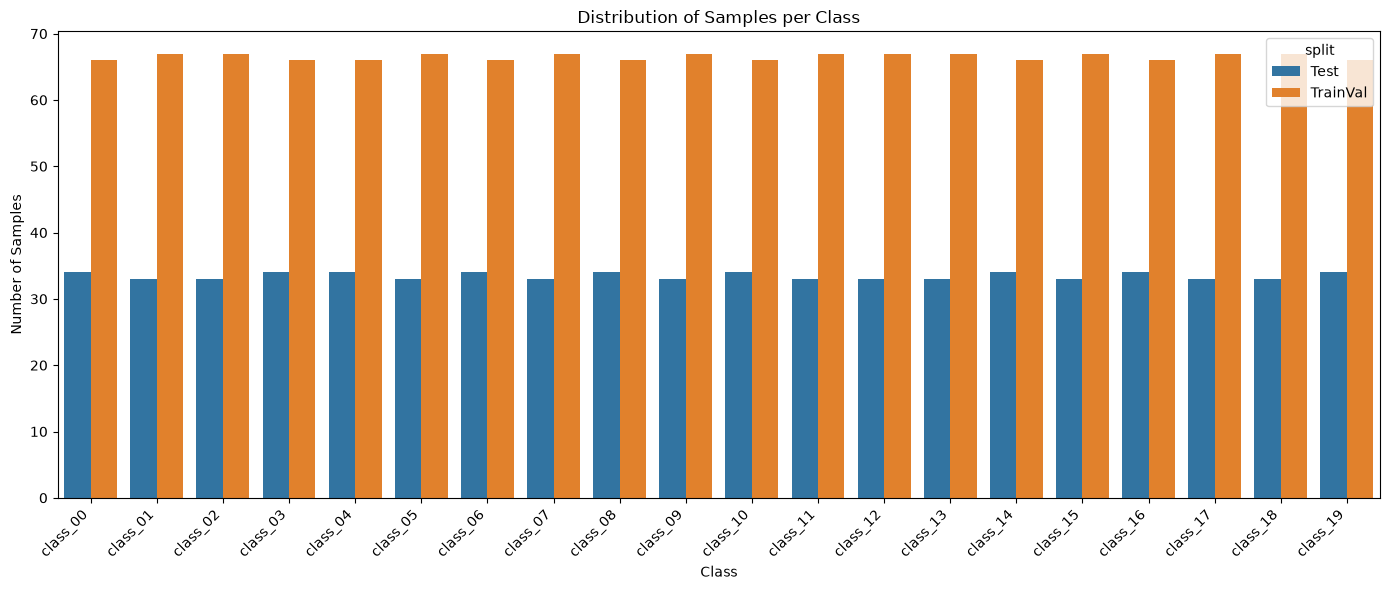

In [4]:

def plot_class_distribution(*datasets, dataset_names=None, figsize=(14, 6)):
    """
    Plot the distribution of samples per class for multiple datasets.
    
    Args:
        *datasets: Variable number of ImageFolder datasets or Subsets
        dataset_names: List of names for each dataset (optional)
        figsize: Figure size (width, height)
    """
    
    if dataset_names is None:
        dataset_names = [f'dataset_{i}' for i in range(len(datasets))]
    
    # Collect data from all datasets
    df_list = []
    for dataset, name in zip(datasets, dataset_names):
        # Handle both ImageFolder and Subset datasets
        if hasattr(dataset, 'samples'):
            # ImageFolder dataset
            labels_full = [label for _, label in dataset.samples]
            class_names = dataset.classes
        else:
            # Subset dataset - get labels from indices
            labels_full = [dataset.dataset.targets[i] for i in dataset.indices]
            class_names = dataset.dataset.classes
        
        df = pd.DataFrame({
            'class': [class_names[label] for label in labels_full],
            'split': name,
            'count': 1
        })
        df_list.append(df)
    
    # Combine all dataframes
    combined_df = pd.concat(df_list)
    
    # Group by class and split, then count
    df_grouped = combined_df.groupby(['class', 'split']).count().reset_index()
    
    # Create grouped bar plot
    plt.figure(figsize=figsize)
    sns.barplot(data=df_grouped, x='class', y='count', hue='split')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Class')
    plt.ylabel('Number of Samples')
    plt.title('Distribution of Samples per Class')
    plt.tight_layout()
    plt.show()

# Plot the distribution
plot_class_distribution(trainval_dataset, test_dataset, dataset_names=['TrainVal', 'Test'])

Total trainval samples: 1331
Training samples: 1064
Validation samples: 267


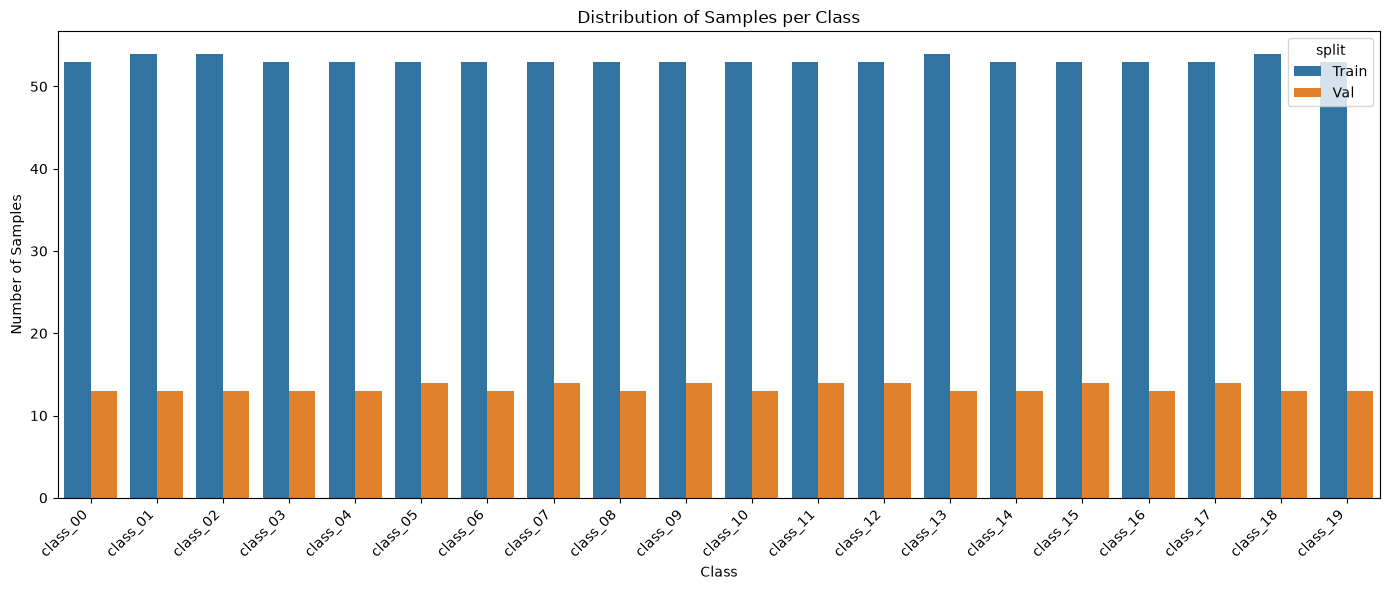

In [14]:
# Perform stratified split to maintain class distribution
indices = list(range(len(trainval_dataset)))
labels = [label for _, label in trainval_dataset.samples]
# Create subset datasets
train_indices, val_indices = train_test_split(indices, test_size=0.2, stratify=labels)

train_dataset = torch.utils.data.Subset(trainval_dataset, train_indices)
val_dataset = torch.utils.data.Subset(copy.deepcopy(trainval_dataset), val_indices)

print(f"Total trainval samples: {len(trainval_dataset)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
plot_class_distribution(train_dataset, val_dataset, dataset_names=['Train', 'Val'])

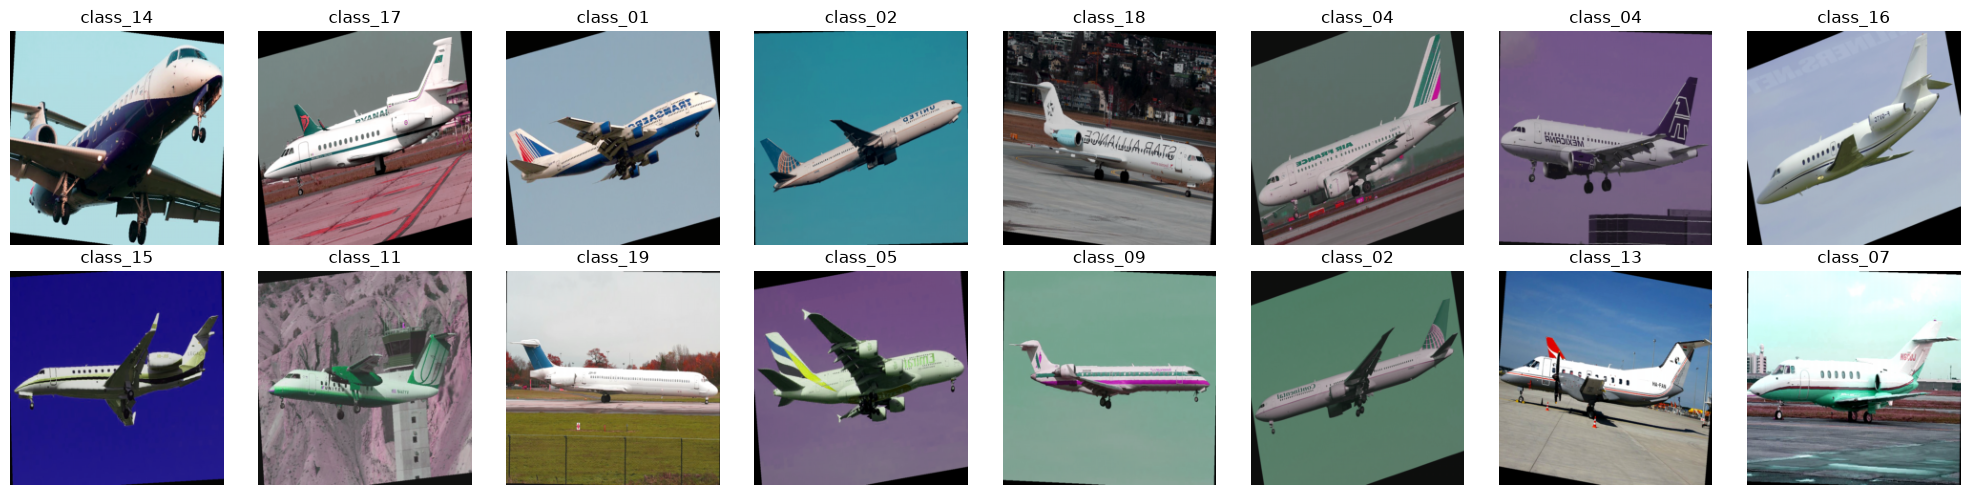

In [22]:

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose([transforms.ToTensor(), transforms.Resize((224, 224)), transforms.Normalize(imagenet_means, imagenet_stds)])


# Data augmentation transforms for training set
train_transform = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2)])

# Apply transforms to the datasets
train_dataset.dataset.transform = transforms.Compose([train_transform,transform])
val_dataset.dataset.transform = transform
test_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Visualize a batch of augmented training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot the batch
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.ravel()
for idx in range(min(16, len(images))):
    # Denormalize the image for visualization
    img = images[idx].numpy().transpose((1, 2, 0))
    # just remap for visualization
    img = img * np.array(imagenet_stds) + np.array(imagenet_means)
    img = np.clip(img, 0, 1)
    
    axes[idx].imshow(img)
    axes[idx].set_title(class_names[labels[idx]])
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [23]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 20, True)
print(resnet_frozen)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [24]:
def train_epoch(model, dataloader, criterion, optimizer, epoch, device):

    # Put the model in "train" mode
    model.train() 

    # For all batches in the training dataset
    train_loss, correct, total = [], 0.0, 0.0
    for _, data in tqdm(enumerate(dataloader, 0), total = len(dataloader), desc = f'Epoch {epoch+1} - training phase'):
        # get the inputs and labels from the dataloader and move to device (GPU or CPU)
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

       # TODO
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += [loss.cpu().item()]
        predicted = torch.argmax(outputs, axis=1)
        correct += torch.sum(predicted==labels).cpu().item()
        total += len(labels)
                            
        
    # average stats for the epoch
    mean_train_loss = np.mean(train_loss)
    train_accuracy = correct/total
    print(f"Training {epoch+1}: loss={mean_train_loss:.3f} acc={train_accuracy:.3f}")

    return mean_train_loss, train_accuracy


In [27]:
def eval_epoch(model, dataloader, criterion, epoch, device):

    # Put the model in "eval" mode
    model.eval()
    
    #Validation loop: For all batches in the validation dataset
    with torch.no_grad(): # not build the computation graph for backpropagation, and thus, no gradients will be computed or stored for the tensors involved in those operations.
        val_loss, val_correct, val_total = 0.0, 0.0, 0.0
        for i, data in tqdm(enumerate(dataloader, 0), total = len(dataloader), desc = f'Epoch {epoch+1} - validation phase'):
            # get the inputs and labels from the dataloader and move to device (GPU or CPU)
            inputs, labels = data            
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # TODO

            outputs = model(inputs)
            predicted =torch.argmax(outputs, axis=1)
            loss = criterion(outputs, labels)

            val_loss += loss.cpu().item() * inputs.size(0)
            val_correct += torch.sum(predicted == labels).cpu().item()
            val_total += inputs.size(0)
    
    mean_val_loss = val_loss / val_total
    val_accuracy = val_correct / val_total
    print(f"Validation {epoch+1}: loss={mean_val_loss:.3f} acc={val_accuracy:.3f}")
    return mean_val_loss, val_accuracy

Epoch 1 - training phase: 100%|██████████| 67/67 [00:43<00:00,  1.55it/s]


Training 1: loss=3.041 acc=0.070


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:03<00:00,  4.73it/s]


Validation 1: loss=2.899 acc=0.101
best model found at 0 with a val accuracy of 0.10112359550561797


Epoch 2 - training phase: 100%|██████████| 67/67 [00:43<00:00,  1.54it/s]


...

Validation 9: loss=1.921 acc=0.476
best model found at 8 with a val accuracy of 0.4756554307116105


Epoch 10 - training phase: 100%|██████████| 67/67 [00:43<00:00,  1.54it/s]


Training 10: loss=1.778 acc=0.513


Epoch 10 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.25it/s]

Validation 10: loss=1.918 acc=0.461


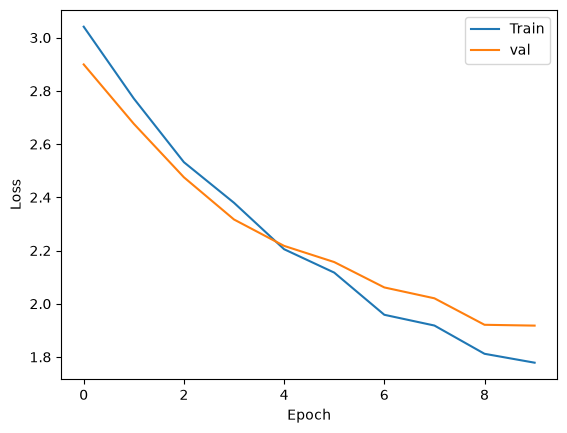

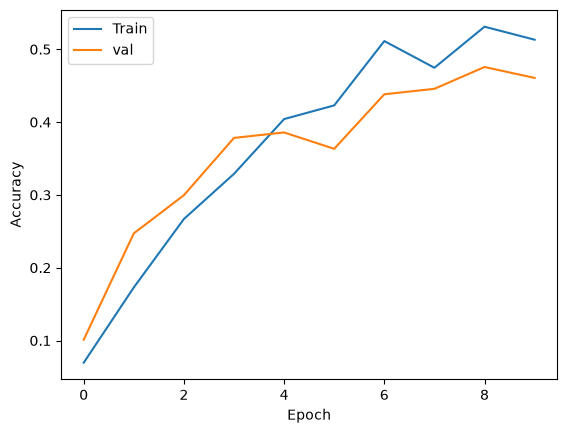

In [28]:
# any hyperparameters
lr = 0.001
total_epochs = 10

#Initialise the model.
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 20, True)
resnet_frozen = resnet_frozen.to(device)
# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the SGD optimizer.
optimizer = optim.SGD(resnet_frozen.parameters(), lr=lr, momentum=0.9)

#Step 4: For n epochs (e.g. loss converged/stops changing)
total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf
for epoch in range(total_epochs):    

    # train for one epoch
    mean_train_loss, train_accuracy = train_epoch(resnet_frozen, trainloader, criterion, optimizer, epoch, device)
    total_train_loss.append(mean_train_loss); total_train_acc.append(train_accuracy);

    # evaluate on validation set
    mean_val_loss, val_accuracy = eval_epoch(resnet_frozen, valloader, criterion, epoch, device)
    total_val_loss.append(mean_val_loss); total_val_acc.append(val_accuracy);

    # save the best model based on validation accuracy
    if val_accuracy > best_acc:
        torch.save(resnet_frozen.state_dict(), "resnet_frozen_best.pth")
        best_acc = val_accuracy
        print(f"best model found at {epoch} with a val accuracy of {best_acc}")

    


# Plot training and validation loss and accuracy curves
plt.plot(total_train_loss, label = 'Train')
plt.plot(total_val_loss, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(total_train_acc, label = 'Train')
plt.plot(total_val_acc, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [29]:
import pickle

# save the baseline results so they can be compared with the experiments later
baseline_results = {
    'train_loss': total_train_loss,
    'val_loss': total_val_loss,
    'train_acc': total_train_acc,
    'val_acc': total_val_acc,
    'best_val_acc': best_acc
}

with open('results_baseline.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print(f"Baseline best validation accuracy: {best_acc:.4f}")

Baseline best validation accuracy: 0.4757


In [32]:
## Optimisation - Experiment 1. 
## Data Arguments - Experiment 2. 
## Hyperparameters - Experiment 3. 

Epoch 1 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


Training 1: loss=3.094 acc=0.065


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.34it/s]


Validation 1: loss=3.028 acc=0.064
best model found at 0 with val acc of 0.06367041198501873


Epoch 2 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.44it/s]


...

Validation 9: loss=2.414 acc=0.341
best model found at 8 with val acc of 0.3408239700374532


Epoch 10 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


Training 10: loss=2.313 acc=0.432


Epoch 10 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.44it/s]


Validation 10: loss=2.324 acc=0.375
best model found at 9 with val acc of 0.37453183520599254


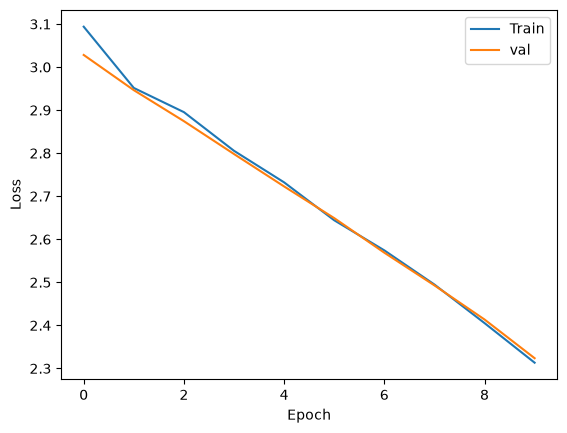

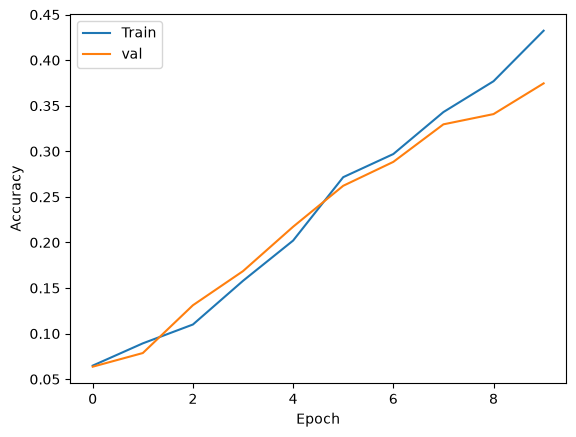

In [30]:
# Experiment 1: unfreeze the backbone (full fine-tuning)
# Hypothesis: the frozen baseline can only use generic ImageNet features. Aircraft
# classification is fine-grained, so the model needs to learn aircraft-specific
# features. Unfreezing the backbone should allow this.
# The learning rate is also reduced to 0.0001, because fine-tuning all layers with
# lr=0.001 would destroy the pretrained weights.

lr = 0.0001
total_epochs = 10

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_ft = setup_model(backbone, 20, False)
resnet_ft = resnet_ft.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet_ft.parameters(), lr=lr, momentum=0.9)

total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf

for epoch in range(total_epochs):    

    mean_train_loss, train_accuracy = train_epoch(resnet_ft, trainloader, criterion, optimizer, epoch, device)
    total_train_loss.append(mean_train_loss); total_train_acc.append(train_accuracy);

    mean_val_loss, val_accuracy = eval_epoch(resnet_ft, valloader, criterion, epoch, device)
    total_val_loss.append(mean_val_loss); total_val_acc.append(val_accuracy);

    if val_accuracy > best_acc:
        torch.save(resnet_ft.state_dict(), "resnet_h1_best.pth")
        best_acc = val_accuracy
        print(f"best model found at {epoch} with val acc of {best_acc}")

plt.plot(total_train_loss, label = 'Train')
plt.plot(total_val_loss, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

plt.plot(total_train_acc, label = 'Train')
plt.plot(total_val_acc, label = 'val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [31]:
h1_results = {
    'train_loss': total_train_loss,
    'val_loss': total_val_loss,
    'train_acc': total_train_acc,
    'val_acc': total_val_acc,
    'best_val_acc': best_acc
}

with open('results_h1.pkl', 'wb') as f:
    pickle.dump(h1_results, f)

print(f"Experiment 1 best validation accuracy: {best_acc:.4f}")

Experiment 1 best validation accuracy: 0.3745


Epoch 1 - training phase: 100%|██████████| 67/67 [00:47<00:00,  1.41it/s]


Training 1: loss=3.140 acc=0.047


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.02it/s]


Validation 1: loss=3.086 acc=0.045
best model found at 0 with val acc of 0.0449438202247191


Epoch 2 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.43it/s]


...

Validation 9: loss=2.492 acc=0.300
best model found at 8 with val acc of 0.299625468164794


Epoch 10 - training phase: 100%|██████████| 67/67 [00:47<00:00,  1.41it/s]


Training 10: loss=2.359 acc=0.403


Epoch 10 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.32it/s]


Validation 10: loss=2.394 acc=0.341
best model found at 9 with val acc of 0.3408239700374532


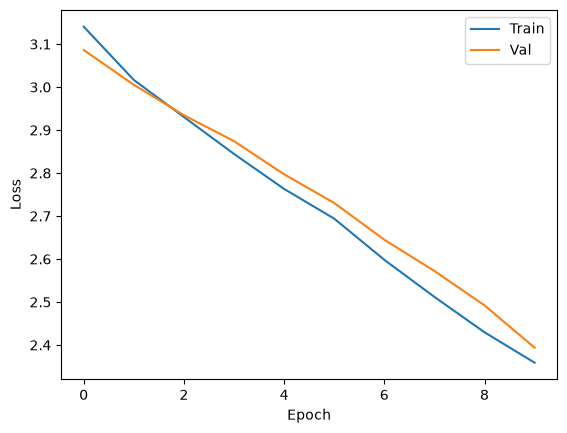

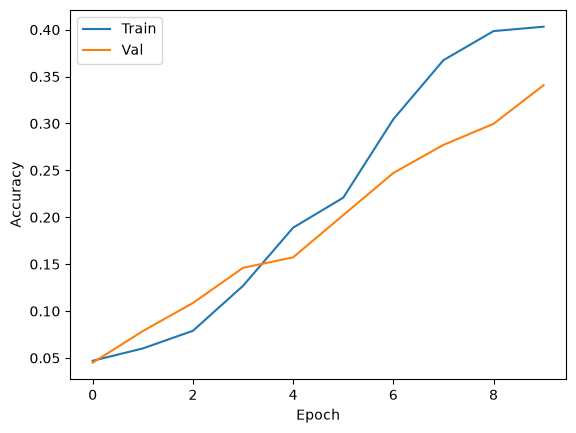

In [33]:
# Experiment 2: add data augmentation to the training set only
# Hypothesis: Aircraft images can vary in orientation, lighting, and appearance.
# Adding data augmentation should expose the model to greater variation during
# training and improve its ability to generalise to unseen aircraft images.
# Only the training set is augmented; validation and test sets use the standard
# preprocessing transform so that evaluation remains consistent.

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])

# Apply augmentation to training images only.
# Validation and test images remain unaugmented.
train_dataset.dataset.transform = transforms.Compose([
    train_transform,
    transform
])

val_dataset.dataset.transform = transform
test_dataset.transform = transform

# Keep the same model, learning rate, optimiser, batch size and number of
# epochs as Experiment 1 so that augmentation is the main variable being tested.

lr = 0.0001
total_epochs = 10

backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

resnet_aug = setup_model(backbone, 20, False)
resnet_aug = resnet_aug.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(
    resnet_aug.parameters(),
    lr=lr,
    momentum=0.9
)

total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf

for epoch in range(total_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        resnet_aug, trainloader, criterion, optimizer, epoch, device
    )
    total_train_loss.append(mean_train_loss)
    total_train_acc.append(train_accuracy)

    mean_val_loss, val_accuracy = eval_epoch(
        resnet_aug, valloader, criterion, epoch, device
    )
    total_val_loss.append(mean_val_loss)
    total_val_acc.append(val_accuracy)

    if val_accuracy > best_acc:
        torch.save(resnet_aug.state_dict(), "resnet_h2_best.pth")
        best_acc = val_accuracy
        print(f"best model found at {epoch} with val acc of {best_acc}")

# Plot loss curves
plt.plot(total_train_loss, label='Train')
plt.plot(total_val_loss, label='Val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Plot accuracy curves
plt.plot(total_train_acc, label='Train')
plt.plot(total_val_acc, label='Val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [34]:

h2_results = {
    'train_loss': total_train_loss,
    'val_loss': total_val_loss,
    'train_acc': total_train_acc,
    'val_acc': total_val_acc,
    'best_val_acc': best_acc
}

with open('results_h2.pkl', 'wb') as f:
    pickle.dump(h2_results, f)

print(f"Experiment 2 best validation accuracy: {best_acc:.4f}")

Experiment 2 best validation accuracy: 0.3408


Epoch 1 - training phase: 100%|██████████| 67/67 [00:46<00:00,  1.45it/s]


Training 1: loss=2.412 acc=0.309


Epoch 1 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.40it/s]


Validation 1: loss=1.590 acc=0.562
best model found at 0 with val acc of 0.5617977528089888


Epoch 2 - training phase: 100%|██████████| 67/67 [00:45<00:00,  1.47it/s]


...

Validation 9: loss=0.609 acc=0.846


Epoch 10 - training phase: 100%|██████████| 67/67 [00:45<00:00,  1.46it/s]


Training 10: loss=0.069 acc=0.993


Epoch 10 - validation phase: 100%|██████████| 17/17 [00:02<00:00,  6.79it/s]


Validation 10: loss=0.472 acc=0.869
best model found at 9 with val acc of 0.8689138576779026


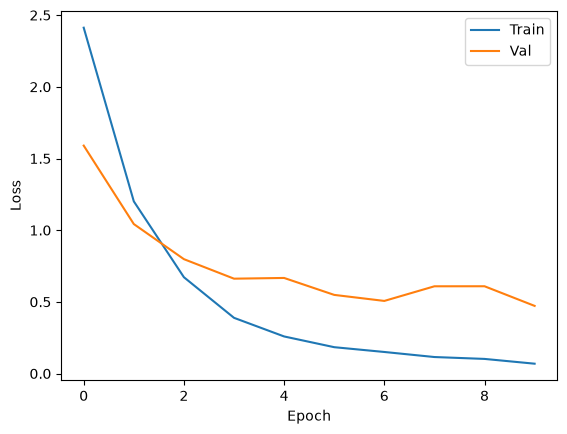

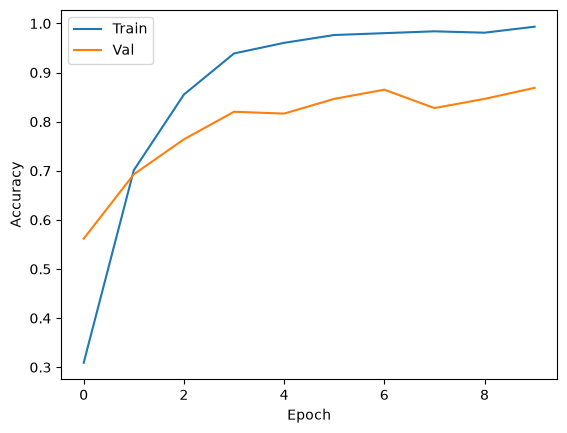

In [36]:
# Experiment 3: change the optimisation strategy
#
# Hypothesis:
# AdamW will improve validation performance compared with SGD by providing
# adaptive parameter updates, potentially allowing the fully fine-tuned
# ResNet-18 to converge more effectively.
#
# Experiment 3 builds on Experiments 1 and 2:
# - ResNet-18
# - Full fine-tuning (unfrozen backbone)
# - Data augmentation on training data only

# ---------------------------------------------------------
# 1. Data augmentation
# ---------------------------------------------------------

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    )
])

# Training data gets augmentation + standard preprocessing
train_dataset.dataset.transform = transforms.Compose([
    train_transform,
    transform
])

# Validation and test data remain unaugmented
val_dataset.dataset.transform = transform
test_dataset.transform = transform

lr = 0.0001
total_epochs = 10

backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

resnet_h3 = setup_model(backbone,20,False)
resnet_h3 = resnet_h3.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(resnet_h3.parameters(),lr=lr)

total_train_loss = []
total_val_loss = []

total_train_acc = []
total_val_acc = []

best_acc = -np.inf

for epoch in range(total_epochs):
    mean_train_loss, train_accuracy = train_epoch(
        resnet_h3,
        trainloader,
        criterion,
        optimizer,
        epoch,
        device
    )

    total_train_loss.append(mean_train_loss)
    total_train_acc.append(train_accuracy)

    mean_val_loss, val_accuracy = eval_epoch(
        resnet_h3,
        valloader,
        criterion,
        epoch,
        device
    )

    total_val_loss.append(mean_val_loss)
    total_val_acc.append(val_accuracy)


    # -----------------------------
    # Save best model
    # -----------------------------

    if val_accuracy > best_acc:

        torch.save(resnet_h3.state_dict(),"resnet_h3_best.pth")
        best_acc = val_accuracy
        print(f"best model found at {epoch} with val acc of {best_acc}")


# Plot loss curves
plt.plot(total_train_loss, label='Train')
plt.plot(total_val_loss, label='Val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Plot accuracy curves
plt.plot(total_train_acc, label='Train')
plt.plot(total_val_acc, label='Val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [37]:

h3_lr01_results = {
    'train_loss': total_train_loss, 'val_loss': total_val_loss,
    'train_acc': total_train_acc, 'val_acc': total_val_acc,
    'best_val_acc': best_acc
}
with open('results_h3.pkl', 'wb') as f:
    pickle.dump(h3_lr01_results, f)

print(f"lr=0.01 best validation accuracy: {best_acc:.4f}")

lr=0.01 best validation accuracy: 0.8689


In [38]:
# Final model: retrain on the whole trainval dataset
# The validation split was only used to select the best configuration.
# We now use all available trainval images for final training.

# Apply the same augmentation used in Experiment 3
# to the entire trainval dataset.
trainval_dataset.transform = transforms.Compose([
    train_transform,
    transform
])

# Create DataLoader for the full trainval dataset
trainvalloader = torch.utils.data.DataLoader(
    trainval_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print(f"Final training set size: {len(trainval_dataset)}")

Final training set size: 1331


In [39]:
# Create a fresh pretrained ResNet-18

backbone = torchvision.models.resnet18(
    weights=torchvision.models.ResNet18_Weights.DEFAULT
)

# False = fully fine-tune the backbone
final_model = setup_model(
    backbone,
    20,
    False
)

final_model = final_model.to(device)

lr = 0.0001
total_epochs = 10

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    final_model.parameters(),
    lr=lr
)

total_train_loss = []
total_train_acc = []

for epoch in range(total_epochs):

    mean_train_loss, train_accuracy = train_epoch(
        final_model,
        trainvalloader,
        criterion,
        optimizer,
        epoch,
        device
    )

    total_train_loss.append(mean_train_loss)
    total_train_acc.append(train_accuracy)

    print(
        f"Epoch {epoch + 1}/{total_epochs} | "
        f"Loss: {mean_train_loss:.4f} | "
        f"Accuracy: {train_accuracy:.4f}"
    )

torch.save(
    final_model.state_dict(),
    "final_model.pth"
)

Epoch 1 - training phase: 100%|██████████| 84/84 [00:57<00:00,  1.47it/s]


Training 1: loss=2.276 acc=0.342
Epoch 1/10 | Loss: 2.2761 | Accuracy: 0.3418


Epoch 2 - training phase: 100%|██████████| 84/84 [00:58<00:00,  1.44it/s]


Training 2: loss=1.083 acc=0.745
Epoch 2/10 | Loss: 1.0828 | Accuracy: 0.7446


Epoch 3 - training phase: 100%|██████████| 84/84 [00:57<00:00,  1.46it/s]


...

Training 8: loss=0.120 acc=0.982
Epoch 8/10 | Loss: 0.1203 | Accuracy: 0.9820


Epoch 9 - training phase: 100%|██████████| 84/84 [00:56<00:00,  1.48it/s]


Training 9: loss=0.104 acc=0.985
Epoch 9/10 | Loss: 0.1044 | Accuracy: 0.9850


Epoch 10 - training phase: 100%|██████████| 84/84 [00:56<00:00,  1.48it/s]


Training 10: loss=0.078 acc=0.989
Epoch 10/10 | Loss: 0.0783 | Accuracy: 0.9895


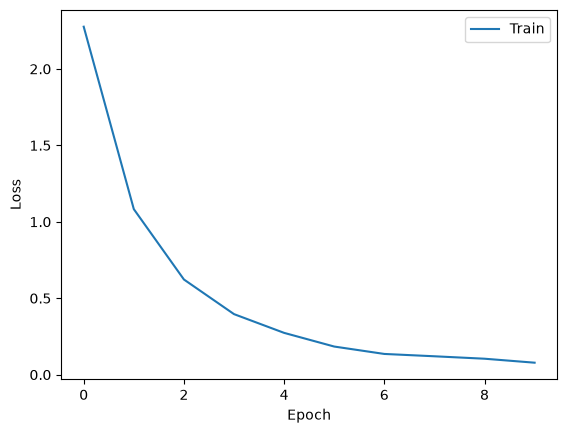

In [40]:
plt.plot(total_train_loss, label = 'Train')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

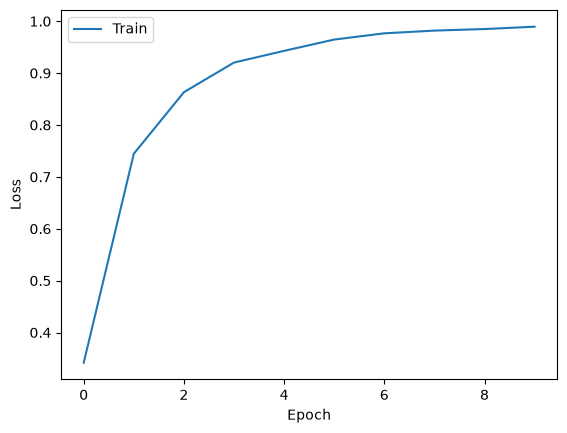

In [41]:
plt.plot(total_train_acc, label = 'Train')
plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.show()

testing: 100%|██████████| 42/42 [00:06<00:00,  6.17it/s]


Overall test accuracy:          0.8864
Average per-class accuracy:     0.8860
Worst class: class_01 (0.6667)
Best class:  class_03 (1.0000)


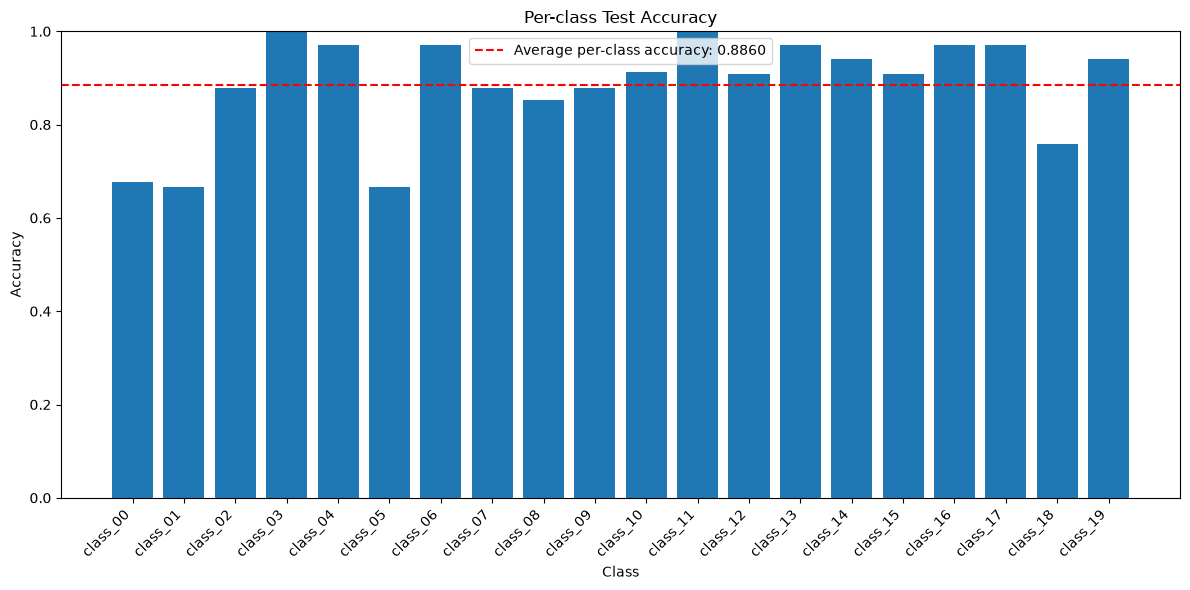

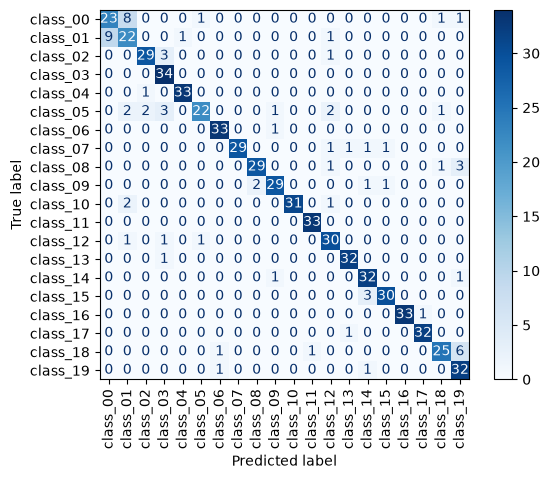

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

# Load the final model and evaluate on the test set
final_model.load_state_dict(torch.load("final_model.pth"))
final_model.eval()

# make sure the test set uses the plain transform (no augmentation)
test_dataset.transform = transform

# Collect predictions and ground truth labels
all_predictions = []
all_labels = []

with torch.no_grad():
    for data in tqdm(testloader, desc="testing"):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = final_model(inputs)
        predicted = torch.argmax(outputs, axis=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Overall accuracy
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
test_accuracy = np.mean(all_predictions == all_labels)

# Per-class accuracy
class_accuracies = []
for class_idx in range(num_classes):
    class_mask = all_labels == class_idx
    class_accuracies.append((all_predictions[class_mask] == all_labels[class_mask]).sum() / float(class_mask.sum()))

# Average per-class accuracy is the metric required by the assignment brief
avg_per_class_accuracy = np.mean(class_accuracies)

print(f"Overall test accuracy:          {test_accuracy:.4f}")
print(f"Average per-class accuracy:     {avg_per_class_accuracy:.4f}")
print(f"Worst class: {class_names[np.argmin(class_accuracies)]} ({np.min(class_accuracies):.4f})")
print(f"Best class:  {class_names[np.argmax(class_accuracies)]} ({np.max(class_accuracies):.4f})")

# Visualize per-class accuracy as a bar plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(class_accuracies)), class_accuracies)
plt.xticks(range(len(class_accuracies)), class_names, rotation=45, ha='right')
plt.xlabel('Class'); plt.ylabel('Accuracy'); plt.title('Per-class Test Accuracy');
plt.ylim([0, 1])
plt.axhline(y=avg_per_class_accuracy, color='r', linestyle='--', label=f'Average per-class accuracy: {avg_per_class_accuracy:.4f}')
plt.legend(); plt.tight_layout(); plt.show();

# Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(all_labels, all_predictions, display_labels=class_names, 
                                               cmap=plt.cm.Blues, xticks_rotation='vertical')

In [47]:

final_results = {
    'train_loss': total_train_loss,
    'train_acc': total_train_acc,
    'test_accuracy': test_accuracy,
    'avg_per_class_accuracy': avg_per_class_accuracy,
    'class_accuracies': class_accuracies,
    'all_predictions': all_predictions,
    'all_labels': all_labels
}

with open('results_final.pkl', 'wb') as f:
    pickle.dump(final_results, f)

print(f"Average per-class accuracy: {avg_per_class_accuracy:.4f}")

Average per-class accuracy: 0.8860
